In [1]:
from utils import * 
import subprocess
import json
from Bio.Align import PairwiseAligner 
import itertools
from dssp import DSSPFile
from files.pdb import cif_to_pdb
from chimerx import * 

import requests
import ast

%load_ext autoreload 
%autoreload 2

ALPHAFOLD_DIR = '../data/genes/alphafold/'
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'
COLABFOLD_OUTPUT_DIR = '../data/genes/colabfold/'

In [2]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id == 1].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_1.faa')
# subprocess.run('muscle -align ../data/genes/cluster_1.faa -output ../data/genes/cluster_1.afa', shell=True, check=True)
for row in genes_df.itertuples():
    print(f'{row.Index}')

print('\nMinimum cluster_1 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_1 gene length:', genes_df.seq.apply(len).max())

orfm.bz_0.1_175
orfm.bz_1.1_148
orfm.bz_2.1_34
orfm.bz_3.1_50
orfm.bz_4.1_164
orfm.bz_5.1_140
orfm.bz_7.1_180
orfm.bz_8.1_206
orfm.bz_9.1_49
orfm.bz_10.1_18
orfm.bz_11.1_39

Minimum cluster_1 gene length: 138
Maximum cluster_1 gene length: 153


In [3]:
outputs = [AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, gene_id)) for gene_id in genes_df.index]
# outputs = [ColabFoldOutput(os.path.join(COLABFOLD_OUTPUT_DIR, get_genome_id(gene_id), gene_id)) for gene_id in genes_df.index]
# Pretty solid improvements in the structures using the custom MSAs! Though confidence is still fairly weak. 
for output in outputs:
    print(output.name, output.get_ptms(best_model=True))

# Copy structures over for DALI search via the web interface. 
for output in outputs:
    output_path = os.path.join('/home/prichter/Downloads/', f'{output.name}.pdb')
    cif_to_pdb(output.best_model_path, output_path=output_path)

orfm.bz_0.1_175 0.46
orfm.bz_1.1_148 0.49
orfm.bz_2.1_34 0.48
orfm.bz_3.1_50 0.5
orfm.bz_4.1_164 0.45
orfm.bz_5.1_140 0.48
orfm.bz_7.1_180 0.4
orfm.bz_8.1_206 0.46
orfm.bz_9.1_49 0.45
orfm.bz_10.1_18 0.47
orfm.bz_11.1_39 0.49


In [4]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    
for row in genes_df.itertuples():
    print(f'Number TMHs in {row.genome_id} cluster_1 protein:', row.num_tmhs)


Number TMHs in bz_0 cluster_1 protein: 0
Number TMHs in bz_1 cluster_1 protein: 0
Number TMHs in bz_2 cluster_1 protein: 0
Number TMHs in bz_3 cluster_1 protein: 0
Number TMHs in bz_4 cluster_1 protein: 0
Number TMHs in bz_5 cluster_1 protein: 0
Number TMHs in bz_7 cluster_1 protein: 0
Number TMHs in bz_8 cluster_1 protein: 0
Number TMHs in bz_9 cluster_1 protein: 0
Number TMHs in bz_10 cluster_1 protein: 0
Number TMHs in bz_11 cluster_1 protein: 0


In [5]:
def plot_entropy(msa:MSAFile, max_entropy=0.2, x_min=20, x_max=70, ax:plt.Axes=None, color:str='gray', alphabet:dict=None, annotate:bool=False, max_gap_fraction=0.2):

    entropy = msa.get_entropy(alphabet=alphabet, max_gap_fraction=max_gap_fraction)

    ax.plot(np.arange(len(entropy)), entropy, color=color)

    if annotate:
        conserved_idxs = np.where((entropy < max_entropy) & (~np.isnan(entropy)))[0] 
        # conserved_idxs = [idx for idx in conserved_idxs if (msa.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
        conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]
        for idx, aas in zip(conserved_idxs, conserved_aas):
            if (idx > x_max) or (idx < x_min):
                continue
            ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
            ax.axvline(idx, color='black', lw=0.5)

    x_ticks = np.arange(x_min, x_max, 2)
    ax.set_xticks(x_ticks, labels=x_ticks, fontsize='xx-small')
    ax.set_xlim(xmin=x_min, xmax=x_max)
    ax.set_ylabel('entropy')
    ax.set_xlabel('position')

Helix 1: 40-61
Helix 2: 71-89
Helix 3: 92-107
Helix 4: 115-123


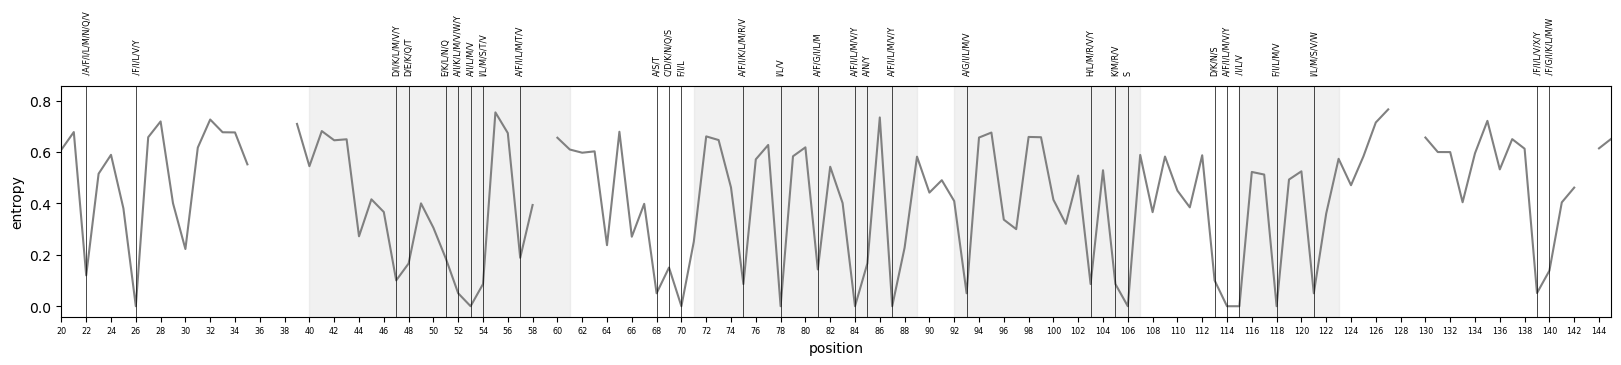

In [6]:

msa_trimmed = MSAFile.from_file('../data/genes/muscle/cluster_1.trimmed.afa') # This is the MSA constructed from all homologs found in ggKbase.
msa = MSAFile.from_file('../data/genes/muscle/cluster_1.afa', clipkit_log_path='../data/genes/muscle/cluster_1.trimmed.afa.log')

helix_1_start = msa.map_idx_to_trimmed_msa(42, 'orfm.bz_0.1_175')
helix_1_stop = msa.map_idx_to_trimmed_msa(62, 'orfm.bz_0.1_175')
print(f'Helix 1: {helix_1_start}-{helix_1_stop}')

helix_2_start = msa.map_idx_to_trimmed_msa(72, 'orfm.bz_0.1_175')
helix_2_stop = msa.map_idx_to_trimmed_msa(90, 'orfm.bz_0.1_175')
print(f'Helix 2: {helix_2_start}-{helix_2_stop}')

helix_3_start = msa.map_idx_to_trimmed_msa(93, 'orfm.bz_0.1_175')
helix_3_stop = msa.map_idx_to_trimmed_msa(108, 'orfm.bz_0.1_175')
print(f'Helix 3: {helix_3_start}-{helix_3_stop}')

helix_4_start = msa.map_idx_to_trimmed_msa(119, 'orfm.bz_0.1_175')
helix_4_stop = msa.map_idx_to_trimmed_msa(127, 'orfm.bz_0.1_175')
print(f'Helix 4: {helix_4_start}-{helix_4_stop}')

helix_idxs = [(helix_1_start, helix_1_stop), (helix_2_start, helix_2_stop), (helix_3_start, helix_3_stop), (helix_4_start, helix_4_stop)]

x_min, x_max = 20, 145
fig, ax = plt.subplots(figsize=(20, 3))
    
alphabet = REDUCED_ALPHABET.copy()
alphabet.update({'Y':'A', 'F':'A', 'W':'A'})

plot_entropy(msa_trimmed, ax=ax, x_min=x_min, x_max=x_max, alphabet=alphabet, annotate=True)
# plot_entropy(dssp_msa, ax=ax, color='lightgray', x_min=x_min, x_max=x_max)

for start, stop in helix_idxs:
    ax.axvspan(start, stop, color='lightgray', alpha=0.3, zorder=-1)

plt.show()

# msa_trimmed.show(start=28, stop=45)

Helix 1: 58-79
Helix 2: 89-107
Helix 3: 110-125
Helix 4: 136-144


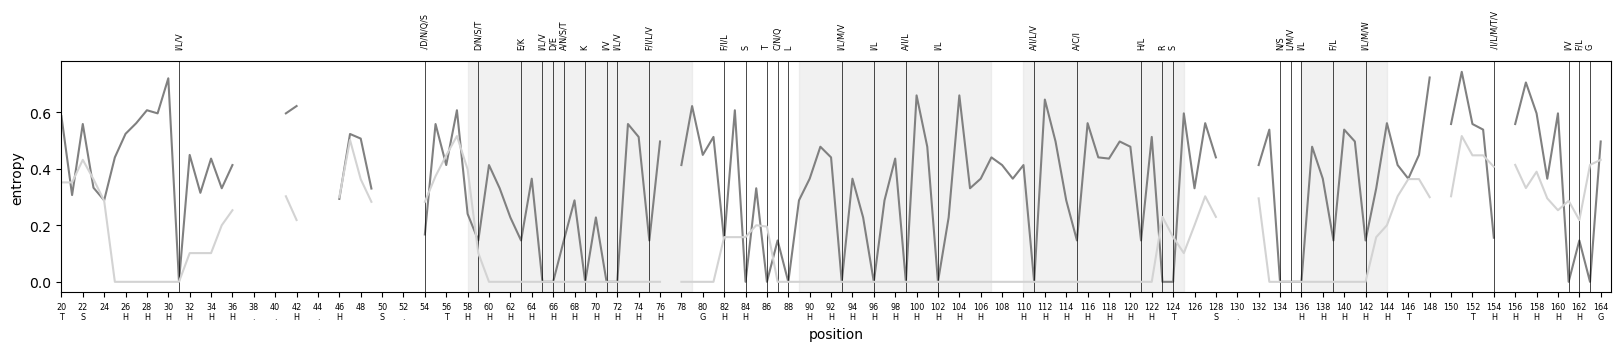

In [7]:
msa = MSAFile.from_file('../data/genes/cluster_1.afa')
dssp_msa = map_dssp_to_msa(msa, dssp_output_dir='../data/genes/dssp')

helix_1_start = msa.map_idx_to_msa(42, 'orfm.bz_0.1_175')
helix_1_stop = msa.map_idx_to_msa(62, 'orfm.bz_0.1_175')
print(f'Helix 1: {helix_1_start}-{helix_1_stop}')

helix_2_start = msa.map_idx_to_msa(72, 'orfm.bz_0.1_175')
helix_2_stop = msa.map_idx_to_msa(90, 'orfm.bz_0.1_175')
print(f'Helix 2: {helix_2_start}-{helix_2_stop}')

helix_3_start = msa.map_idx_to_msa(93, 'orfm.bz_0.1_175')
helix_3_stop = msa.map_idx_to_msa(108, 'orfm.bz_0.1_175')
print(f'Helix 3: {helix_3_start}-{helix_3_stop}')

helix_4_start = msa.map_idx_to_msa(119, 'orfm.bz_0.1_175')
helix_4_stop = msa.map_idx_to_msa(127, 'orfm.bz_0.1_175')
print(f'Helix 4: {helix_4_start}-{helix_4_stop}')

helix_idxs = [(helix_1_start, helix_1_stop), (helix_2_start, helix_2_stop), (helix_3_start, helix_3_stop), (helix_4_start, helix_4_stop)]

x_min, x_max = 20, 165
fig, ax = plt.subplots(figsize=(20, 3))
    

plot_entropy(msa, ax=ax, x_min=x_min, x_max=x_max, alphabet=REDUCED_ALPHABET, annotate=True, max_gap_fraction=0.2)
plot_entropy(dssp_msa, ax=ax, color='lightgray', x_min=x_min, x_max=x_max)

for start, stop in helix_idxs:
    ax.axvspan(start, stop, color='lightgray', alpha=0.3, zorder=-1)

dssp_consensus = dssp_msa.get_consensus()
x_ticks = np.arange(x_min, x_max, 2)
x_tick_labels = [f'{x}\n{dssp_consensus[x]}' for x in x_ticks]
ax.set_xticks(x_ticks, x_tick_labels, fontsize='xx-small')

plt.show()
# msa.show(start=35, stop=50)

In [8]:
CHIMERX_DIR = '../data/genes/chimerx'
os.makedirs(CHIMERX_DIR, exist_ok=True)

gene_id = genes_df.iloc[0].name
cif_path = AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, gene_id)).best_model_path
seq = genes_df.loc[gene_id].seq 

entropies = msa.get_entropy(alphabet=REDUCED_ALPHABET)
attrs_df = pd.DataFrame({'residue_num':np.arange(len(seq)) + 1}) # Needs to be one-indexed for the PDB file. 
attrs_df['entropy'] = attrs_df.residue_num.apply(lambda i : entropies[msa.map_idx_to_msa(i - 1, gene_id)]) # Map the residue number to the MSA and get the entropy. 
attrs_df['residue'] = attrs_df.residue_num.apply(lambda i : seq[i - 1]) # For checking.
attrs_df['chain_id'] = 'A'

attrs_path = os.path.abspath(os.path.join(CHIMERX_DIR, f'{gene_id}-entropy.defattr'))
chimerx_write_attrs('entropy', attrs_df, path=attrs_path)

aas = {'A':'ALA','R':'ARG','N':'ASN','D':'ASP','C':'CYS','E':'GLU','Q':'GLN','G':'GLY','H':'HIS','I':'ILE','L':'LEU','K':'LYS','M':'MET','F':'PHE','P':'PRO','S':'SER','T':'THR','W':'TRP','Y':'TYR','V':'VAL'}
colors = ["#8B6B4D","#7E8B3D","#3868A0", "#7C2E7B"]

residues = {aa:colors[0] for aa in 'KR'}
# residues.update({aa:colors[1] for aa in 'YFW'})
# residues.update({aa:colors[2] for aa in 'NQSTH'})
residues.update({aa:colors[3] for aa in 'AILMFWVY'}) # Hydrophobic.
residues = {aas.get(aa):color for aa, color in residues.items()}

def chimerx_get_command(path:str, attrs_path:str=None, attrs_name:str=None, palette:str='blue:white', residues=dict()):
    ''''''
    cmd = [f'open {path}'] + ['set bgColor white'] + ['color black']

    if attrs_path is not None:
        cmd += [f'open {attrs_path}; color byattribute {attrs_name} palette {palette}']
    for aa, color in residues.items():
        cmd += [f'sel :{aa}; color sel {color}']
    cmd = '; '.join(cmd)
    
    cmd = f'chimerax --cmd "{cmd}"'
    print(cmd)
    return cmd 

chimerx_get_command(cif_path, attrs_path=attrs_path, attrs_name='entropy')
chimerx_get_command(cif_path, residues=residues)


chimerax --cmd "open /home/prichter/Documents/banfield/betazoid/data/genes/alphafold/af_output/orfm.bz_0.1_175/seed-3_sample-0/model.cif; set bgColor white; color black; open /home/prichter/Documents/banfield/betazoid/data/genes/chimerx/orfm.bz_0.1_175-entropy.defattr; color byattribute entropy palette blue:white"
chimerax --cmd "open /home/prichter/Documents/banfield/betazoid/data/genes/alphafold/af_output/orfm.bz_0.1_175/seed-3_sample-0/model.cif; set bgColor white; color black; sel :LYS; color sel #8B6B4D; sel :ARG; color sel #8B6B4D; sel :ALA; color sel #7C2E7B; sel :ILE; color sel #7C2E7B; sel :LEU; color sel #7C2E7B; sel :MET; color sel #7C2E7B; sel :PHE; color sel #7C2E7B; sel :TRP; color sel #7C2E7B; sel :VAL; color sel #7C2E7B; sel :TYR; color sel #7C2E7B"


'chimerax --cmd "open /home/prichter/Documents/banfield/betazoid/data/genes/alphafold/af_output/orfm.bz_0.1_175/seed-3_sample-0/model.cif; set bgColor white; color black; sel :LYS; color sel #8B6B4D; sel :ARG; color sel #8B6B4D; sel :ALA; color sel #7C2E7B; sel :ILE; color sel #7C2E7B; sel :LEU; color sel #7C2E7B; sel :MET; color sel #7C2E7B; sel :PHE; color sel #7C2E7B; sel :TRP; color sel #7C2E7B; sel :VAL; color sel #7C2E7B; sel :TYR; color sel #7C2E7B"'

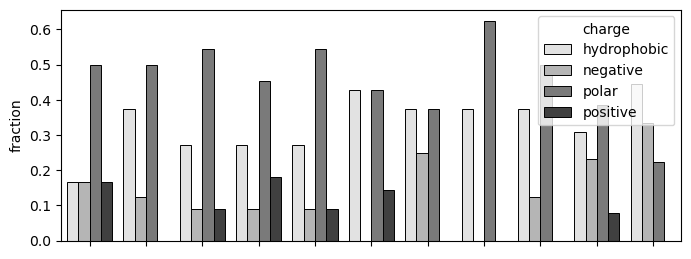

In [9]:
# I think the electrostatic surface may not be particularly meaningful, especially considering how low the pTM is. Instead, want to see how enriched the helices are
# for residues of a particular charge.  


def plot_composition(msa, idxs=None):
    CHARGES = {aa:charge for charge, aas in {'positive':'KRH', 'negative':'DE', 'hydrophobic':'AVILMFWY', 'polar':'STNQCGP', 'none':'.X'}.items() for aa in aas}

    # idxs = (helix_3_start, helix_3_stop)
    # idxs = (40, 61)

    figure_df = list()

    for gene_id, seq in zip(msa.ids, msa.seqs):
        seq = seq[idxs[0]:idxs[1]]
        seq = seq.replace(msa.gap_symbol, '')
        charges = [CHARGES.get(aa) for aa in seq]
        for charge, count in zip(*np.unique(charges, return_counts=True)):
            figure_df.append({'gene_id':gene_id, 'charge':charge, 'count':count, 'fraction':count/len(seq)})
    figure_df = pd.DataFrame(figure_df)
    figure_df = figure_df[figure_df.charge != 'none'].copy()
    # figure_df = figure_df[figure_df.charge != 'hydrophobic'].copy()

    fig, ax = plt.subplots(figsize=(8, 3))
    sns.barplot(figure_df, x='gene_id', hue='charge', y='fraction', palette='Grays', edgecolor='black', linewidth=0.7)
    ax.set_xlabel('')
    # ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), rotation=90)
    ax.set_xticks(ax.get_xticks(), labels=[])
    plt.show()

plot_composition(msa, idxs=(35, 50))

In [11]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/level_1_conserved_clusters*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)]


target_header_map = dict()
target_header_map['A0A649VKB1'] = 'RNA polymerase sigma factor'
target_header_map['A0A8S5VJW2'] = 'Uncharacterized protein'
target_header_map['A0A516M315'] = 'Uncharacterized protein'
target_header_map['A0A0B4ZZ91'] = 'DUF5132 domain-containing protein' # See https://www.ebi.ac.uk/interpro/entry/pfam/PF17195/
target_header_map['H6SU45'] = 'Uncharacterized protein'
target_header_map['S5VZJ8'] = 'Uncharacterized protein'
target_header_map['A0A2I2L3Z6'] = 'Nucleotidyltransferase'
target_header_map['A0A7G9U8E2'] = 'Uncharacterized protein'
target_header_map['A0A1S6L1J1'] = 'Uncharacterized protein'
target_header_map['A0A2I7QII9'] = 'Uncharacterized protein'
target_header_map['A0A6J5NUG'] = 'Uncharacterized protein'
target_header_map['A0A6J5M230'] = 'Bacteriophage holin family'
target_header_map['A0A6J5NUG2'] = 'Uncharacterized protein'
target_header_map['A0A8S0I5L0'] = 'Uncharacterized protein'
target_header_map['A0A8K1XCN6'] = 'Uncharacterized protein'
target_header_map['A0A6J7X3A6'] = 'Uncharacterized protein'
target_header_map['S5DYW3'] = 'Uncharacterized protein'
target_header_map['A0A8S5KXL3'] = 'Uncharacterized protein'
target_header_map['K4ER51'] = 'Uncharacterized protein'
target_header_map['M1IDE4'] = 'Uncharacterized protein'
target_header_map['A0A068ABV6'] = 'Uncharacterized protein'
target_header_map['A0A0F7L139'] = 'Uncharacterized protein'

foldseek_search_df['target_header'] = foldseek_search_df.target_header.apply(lambda header : target_header_map.get(header, header))

In [55]:
filters = dict()
filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.5
# filters['low_query_coverage'] = foldseek_search_df.query_coverage < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 100
filters['long_alignment'] = foldseek_search_df.alignment_length > 300
filters['synthetic'] = foldseek_search_df.target_header.str.contains('design|synthetic|de novo|engineered|artificial|7yh8|6j2l|6ovh|8den', case=False)

foldseek_search_df = apply_filters(filters, foldseek_search_df)

# The Foldseek hits from the structures created using the custom MSAs are pretty similar
categories = dict()
categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized|Uncharacterized protein|2ehw|membrane protein', case=False)
categories['nucleotidyltransferase'] = foldseek_search_df.target_header.str.contains('Nucleotidyltransferase', case=False)
categories['RNA polymerase sigma factor'] = foldseek_search_df.target_header.str.contains('RNA polymerase sigma factor|sigma factor', case=False)
categories['pilin'] = foldseek_search_df.target_header.str.contains('pilin', case=False)
categories['RNA-binding protein'] = foldseek_search_df.target_header.str.contains('RNA-binding protein|7qv3-assembly1_o')
categories['DNA-binding protein'] = foldseek_search_df.target_header.str.contains('transcription factor', case=False)
categories['DNA repair protein'] = foldseek_search_df.target_header.str.contains('DNA repair')
categories['PsiE'] = foldseek_search_df.target_header.str.contains('PsiE') # This is a small membrane protein, so probably a false positive. 
categories['PspA'] = foldseek_search_df.target_header.str.contains('PspA') # This is a small membrane protein, so probably a false positive. 
categories['mcdB'] = foldseek_search_df.target_header.str.contains('Maintenance of carboxysome distribution', case=False) # Maintenance of carboxysome distribution protein B
categories['Spcs1'] = foldseek_search_df.target_header.str.contains('Signal peptidase complex', case=False)
categories['serine-tRNA ligase'] = foldseek_search_df.target_header.str.contains('serine--tRNA', case=False)
categories['ALK'] = foldseek_search_df.target_header.str.contains('ALK') # A receptor tyrosine kinase
categories['DNA polymerase alpha catalytic subunit'] = foldseek_search_df.target_header.str.contains('8b9d-assembly1_B') # Apparently chain B, see https://www.rcsb.org/annotations/8B9D
categories['transport protein'] = foldseek_search_df.target_header.str.contains('TRPC3') # This specifically corresponds to the cytoplasmic domain. Actually looks fairly similar. 
categories['fumarate reductase'] = foldseek_search_df.target_header.str.contains('Fumarate')
categories['ribonuclease'] = foldseek_search_df.target_header.str.contains('exodeoxyribonuclease|ribonuclease', case=False)
categories['HistIE'] = foldseek_search_df.target_header.str.contains('histidine biosynthesis', case=False)
categories['CASP-like'] = foldseek_search_df.target_header.str.contains('CASP', case=True) # A CASP-like protein generally refers to a protein related to Cytoplasmic Accessory Secretion Proteins (CASPs). These are generally membrane-associated.
categories['capsid'] = foldseek_search_df.target_header.str.contains('capsid') # https://www.rcsb.org/sequence/8AAC
categories['AAA ATPase oligomerization domain'] = foldseek_search_df.target_header.str.contains('3ctd') # https://www.rcsb.org/annotations/3CTD
categories['YidH'] = foldseek_search_df.target_header.str.contains('YidH|membrane insertion', case=False)
categories['EEP superfamily'] = foldseek_search_df.target_header.str.contains('Endonuclease/exonuclease/phosphatase')
categories['FliS'] = foldseek_search_df.target_header.str.contains('FliS') # Flagellar secretion chaperone. 
categories['G-protein coupled receptor'] = foldseek_search_df.target_header.str.contains('G-protein|G protein| G Protein')
categories['CowN'] = foldseek_search_df.target_header.str.contains('fixation sustaining protein CowN') 
categories['Skp'] = foldseek_search_df.target_header.str.contains('Skp') # Chaperone. 
categories['DarP'] = foldseek_search_df.target_header.str.contains('Dual-action ribosomal maturation protein DarP') # rRNA and RNA binding features.
categories['RxLR effector protein'] = foldseek_search_df.target_header.str.contains('RxLR effector protein') 
categories['kinase'] = foldseek_search_df.target_header.str.contains('protein kinase') 
categories['CpxP'] = foldseek_search_df.target_header.str.contains('CpxP') # This is a protein chaperone. 
categories['holin'] = foldseek_search_df.target_header.str.contains('holin', case=False) 
categories['ATPase'] = foldseek_search_df.target_header.str.contains('ATPase') 
categories['ion channel'] = foldseek_search_df.target_header.str.contains('cation efflux protein|proton channel|copper transport|hydrogen channel', case=False) 
categories['DUF202 domain-containing protein'] = foldseek_search_df.target_header.str.contains('DUF202') # https://www.ebi.ac.uk/interpro/entry/InterPro/IPR003807/
categories['FHA domain-containing protein'] = foldseek_search_df.target_header.str.contains('FHA') # This is a small protein–protein interaction domain.
categories['vacuolar transporter chaperone'] = foldseek_search_df.target_header.str.contains('Vacuolar transporter') 
categories['ferritin'] = foldseek_search_df.target_header.str.contains('ferritin', case=False) # Stores iron inside a protein shell and releases it when needed.
categories['ribosomal subunit'] = foldseek_search_df.target_header.str.contains('ribosomal subunit|ribosome|robosomal', case=False) 
categories['ATP synthase'] = foldseek_search_df.target_header.str.contains('ATP synthase', case=False) 
categories['type III secretion system'] = foldseek_search_df.target_header.str.contains('type III secretion', case=False) 
categories['type VI secretion system'] = foldseek_search_df.target_header.str.contains('ImpI', case=False) # This is membrane-associated.

# 7qv3-assembly1_o corresponds to the RNA-binding domain of 30S ribosomal protein S15 in the complex, see https://www.rcsb.org/sequence/7QV3#UA
# 8umt-assembly1_A corresponds to an ATPase in a complex with a clamp loader https://www.rcsb.org/annotations/8UMT. The alignment doesn't make any sense though
# 8sry-assembly1_D is a domain of a signalling protein, looks like a false positive.
# Q60I27 Regulates a GTPase, but looking at structure it seems to be a false positive.
# PspA/IM30 is also a membrane protein involved in stress response.

categories = list(zip(*list(categories.items())))
foldseek_search_df['category'] = np.select(*categories[::-1], default='none')




apply_filters: 0 entries removed by low_tm_score.
apply_filters: 392 entries removed by short_alignment.
apply_filters: 0 entries removed by long_alignment.
apply_filters: 0 entries removed by synthetic.


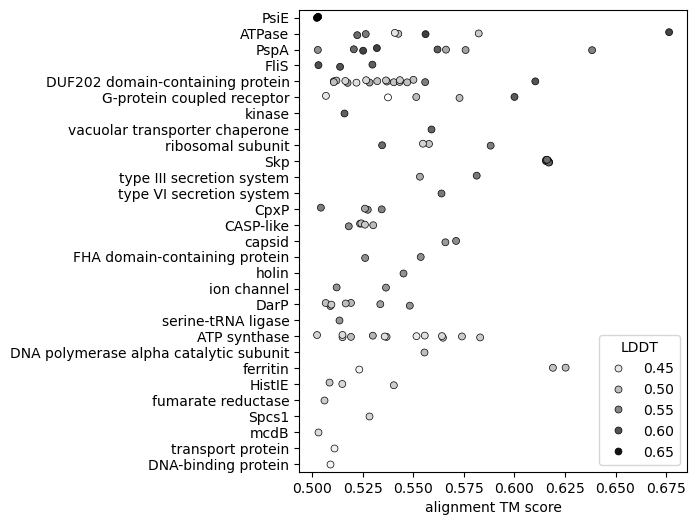

In [56]:
fig, ax = plt.subplots(figsize=(5, 6))

figure_df = foldseek_search_df[~foldseek_search_df.category.isin(['none', 'uncharacterized'])].copy()
figure_df = figure_df.sort_values('lddt', ascending=False).drop_duplicates('target_id') # Keep the best hit to each target. 
sns.stripplot(figure_df, y='category', x='alignment_tm_score', ax=ax, hue='lddt', palette='Grays', edgecolor='black', linewidth=0.5)
ax.set_xlabel('alignment TM score')
ax.get_legend().set_title('LDDT')
ax.set_ylabel('')
plt.show()

In [54]:
foldseek_search_df[foldseek_search_df.target_header.str.contains('8umt-assembly1_A')][['target_start', 'target_end', 'target_length', 'alignment_length', 'query_length']]
foldseek_search_df[foldseek_search_df.category == 'none'][['target_header', 'target_start', 'target_end', 'target_length', 'alignment_length', 'query_length']].target_header.drop_duplicates().tolist()
foldseek_search_df.category.value_counts()
foldseek_search_df[foldseek_search_df.category.str.contains('nucl')]

,query_id,target_id,e_value,num_gaps,percent_identity,fraction_identical,num_identical,query_start,query_end,query_length,...,lineage,lddt,lddt_full,query_tm_score,target_tm_score,alignment_tm_score,rmsd,probability,path,category
9720,orfm.bz_7.1_180,1vp7-assembly1_B,0.3055,8,4.3,0.043,3,73,134,150,...,-_cellular organisms;-_Bacteria;k_Pseudomonada...,0.5262,"0.412,0.367,0.481,0.477,0.645,0.602,0.485,0.61...",0.2649,0.4323,0.5006,3.905,0.051,../data/genes/foldseek/level_1_conserved_clust...,ribonuclease
9954,orfm.bz_1.1_148,A0A2I2L3Z6,0.2772,1,4.0,0.040,2,58,105,142,...,d_Viruses;-_Varidnaviria;k_Bamfordvirae;p_Nucl...,0.7117,"0.317,0.483,0.470,0.500,0.576,0.663,0.583,0.53...",0.2973,0.2759,0.7552,2.452,0.076,../data/genes/foldseek/level_1_conserved_clust...,nucleotidyltransferase
4737,orfm.bz_10.1_18,AF-Q6P5S7-F1-model_v6,0.3117,14,1.0,0.010,1,44,132,148,...,-_cellular organisms;-_Eukaryota;-_Opisthokont...,0.4575,"0.340,0.359,0.231,0.539,0.359,0.297,0.446,0.43...",0.3307,0.3511,0.5281,4.280,0.090,../data/genes/foldseek/level_1_conserved_clust...,ribonuclease


In [ ]:

DALI_FIELD_MAP = dict()
DALI_FIELD_MAP['query'] = 'query_id'
DALI_FIELD_MAP['sbjct'] = 'target_id'
DALI_FIELD_MAP['seq_identity'] = 'percent_identity'
DALI_FIELD_MAP['sbjct_sequence'] = 'target_seq'
DALI_FIELD_MAP['sbject_length'] = 'target_length'
DALI_FIELD_MAP['sbjct_sequence'] = 'target_seq'
DALI_FIELD_MAP['compressed_sbjct_dssp'] = 'target_dssp'
DALI_FIELD_MAP['sstarts'] = 'target_starts'
DALI_FIELD_MAP['lengths'] = 'alignment_lengths'
DALI_FIELD_MAP['qstarts'] = 'query_starts'
DALI_FIELD_MAP['all_pfam'] = 'pfam_data'
DALI_FIELD_MAP['ali_length'] = 'alignment_length'


In [ ]:
dali_search_df = pd.concat([pd.read_csv(path, sep='\t', comment='#').assign(path=path) for path in glob.glob('../data/genes/dali/*')]).drop(columns=['query'])
dali_search_df['query_id'] = [os.path.basename(path).replace('.tsv', '') for path in dali_search_df.path]
dali_search_df.columns = dali_search_df.columns.str.replace('-', '_')
dali_search_df = dali_search_df.rename(columns=DALI_FIELD_MAP)


def get_pfam_data(df):
    ''''''
    fields = ['pfam', 'pfam_group', 'pfam_start', 'pfam_stop', 'pfam_e_value']

    df_ = list()
    for row in df.itertuples():
        data = ast.literal_eval(row.pfam_data)
        rows = [dict(zip(fields, entry)) for entry in data]
        for row_ in rows:
            row_['pfam_hit_in_alignment'] = not ((row_['pfam_start'] > row.target_stop) or (row_['pfam_stop'] < row.target_start))
            # Need to include both the query and target ID so that the pfam_hit_in_alignment field is relevant.
            row_['target_id'] = row.target_id
            row_['query_id'] = row.query_id
        df_ += rows
    return pd.DataFrame(df_)


def get_alignment_data(df):
    ''''''
    parse = lambda idxs : ast.literal_eval(re.sub(r'(?<=\d)\s+(?=\d)', ', ', idxs))
    df['query_starts'] = df['query_starts'].apply(parse)
    df['target_starts'] = df['target_starts'].apply(parse)
    df['alignment_lengths'] = df['alignment_lengths'].apply(parse)

    df_ = list()
    for row in df.itertuples():
        row_ = {'query_id':row.query_id, 'target_id':row.target_id}
        row_['query_start'], row_['query_stop'] = min(row.query_starts), max(row.query_starts) + row.alignment_lengths[-1]
        row_['target_start'], row_['target_stop'] = min(row.target_starts), max(row.target_starts) + row.alignment_lengths[-1]
        df_.append(row_)

    return pd.DataFrame(df_)


dali_search_df = dali_search_df.merge(get_alignment_data(dali_search_df), on=['query_id', 'target_id'], how='left')
dali_search_df = dali_search_df.merge(get_pfam_data(dali_search_df), on=['query_id', 'target_id'], how='left')


filters = dict()
filters['low_z_score'] = dali_search_df.z_score < 3
filters['high_rmsd'] = dali_search_df.rmsd > 5


apply_filters(filters, dali_search_df).sort_values('z_score').drop_duplicates('target_id').iloc[-20:]



apply_filters: 13057 entries removed by low_z_score.
apply_filters: 14809 entries removed by high_rmsd.


,database,target_id,z_score,rmsd,alignment_length,sbjct_length,percent_identity,target_seq,target_dssp,description,...,query_start,query_stop,target_start,target_stop,pfam,pfam_group,pfam_start,pfam_stop,pfam_e_value,pfam_hit_in_alignment
15298,PDB,7jznE,4.3,1.8,43,64,5,NDDELHMLMTDLVYEALHFAKDEEIKKRVFQLFELADKAYKNNDRQ...,1L17H4L19H3L19H1L,MOLECULE: SPIKE GLYCOPROTEIN;,...,55,100,11,62,NaN,NaN,NaN,NaN,NaN,NaN
48,PDB,6dk8C,4.3,3.8,64,226,6,AEFLAKISHEIRTPMNGVLGMTELLLGTPLSAKQRDYVQTIHSAGN...,11L14H6L31H8L4E18H3L6E6L4E1L18H4L9E6L8E6L9H10L...,MOLECULE: RETS (REGULATOR OF EXOPOLYSACCHARIDE...,...,55,128,1,227,PF00512,CL0025,1.0,64.0,3.400000e-20,True
15299,PDB,5lufW,4.3,3.4,51,72,0,XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX...,4L15H6L16H6L24H1L,"MOLECULE: CYTOCHROME B-C1 COMPLEX SUBUNIT 1, M...",...,4,101,1,72,NaN,NaN,NaN,NaN,NaN,NaN
5685,PDB,22ibD,4.4,4.0,65,553,8,QEQLKIIKKELGLEKDDKDAIEEKFRERLKELVVPKHVMDVVDEEL...,1L8H12L9H5L16H5L14H13L11H4L17H7L4E8L10H3L4E7L3...,"MOLECULE: LON PROTEASE HOMOLOG, MITOCHONDRIAL;",...,65,145,27,99,NaN,NaN,NaN,NaN,NaN,NaN
39,PDB,9bj7V,4.4,1.5,38,152,11,STDDLNKCIDHISVLIKDAYLLYTNESFATSTFISITIIEEVGKTH...,1L23H3L20H15L6H1L13H1L8H4L3E2L3E1L3H3L18H6L17H1L,MOLECULE: ABIV FAMILY ABORTIVE INFECTION PROTEIN;,...,68,106,4,49,PF18728,CL0291,6.0,47.0,7.700000e-13,True
15266,PDB,3ihuA,4.4,3.7,59,205,7,SASDTVFFGIXSGLELGTFVPGQRLVETDLVAHFGVGRNSVREALQ...,1L15H7L2E1L8H3L13H3L3E5L3E4L25H3L19H3L19H2L11H...,"MOLECULE: TRANSCRIPTIONAL REGULATOR, GNTR FAMILY;",...,1,101,68,141,PF07729,CL0388,74.0,196.0,3.400000e-10,True
15271,PDB,4uq8W,4.4,3.3,49,72,0,XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX...,4L15H6L16H6L24H1L,MOLECULE: NADH UBIQUINONE OXIDOREDUCTASE CHAIN 3;,...,4,101,1,72,NaN,NaN,NaN,NaN,NaN,NaN
15273,PDB,6gdjB,4.4,2.3,47,69,2,PAPLSTMQTALMRLRTYHPSPIILKPVEQAVNHAITLVNTSPSSVV...,2L13H5L20H3L25H1L,MOLECULE: MTO2;,...,55,104,13,70,NaN,NaN,NaN,NaN,NaN,NaN
15272,PDB,8g6rC,4.4,1.9,41,62,10,KLTDIKCSNVVLLGCLSSMNVSANSTEWAYCVDLHNKINLCNDPEK...,1L17H2L3H1L16H3L18H1L,MOLECULE: NSP12;,...,54,98,14,63,PF08716,PF08716,1.0,62.0,1.700000e-26,True
15249,PDB,3bbzB,4.5,1.9,41,48,5,GQKVMITKMITDSVANPQMKQAFEQRLAKASTEDALNDIKRDIIRSAI,1L12H3L13H3L14H2L,MOLECULE: P PROTEIN;,...,55,99,8,49,PF03210,PF03210,1.0,44.0,2.100000e-11,True


In [ ]:
# # First want to evaluate the quality of the ColabFold structures. 
# COLABFOLD_DIR = '../data/genes/colabfold/'
# COLABFOLD_PDB_FILE_NAME_PATTERN = r'*_relaxed_rank_001_alphafold2_ptm_model*.pdb'
# COLABFOLD_SCORES_FILE_NAME_PATTERN = r'*_scores_rank_001_alphafold2_ptm_model*.json'
# COLABFOLD_PLDDTS = dict()

# for path in glob.glob(os.path.join(COLABFOLD_DIR, '*', COLABFOLD_SCORES_FILE_NAME_PATTERN)):    
#     if get_gene_id(path) not in genes_df.index.values: 
#         continue 

#     with open(path, 'r') as f:
#         scores = json.load(f)
#         plddts = np.array(scores['plddt'])
#         COLABFOLD_PLDDTS[get_gene_id(path)] = plddts

# # cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
# # palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}
# # fig, ax = plt.subplots(figsize=(10, 3.5))
# # for gene_id, plddts in COLABFOLD_PLDDTS.items():
# #     ax.plot(np.arange(len(plddts)), plddts, label=gene_id, color=palette[gene_id])
# # ax.set_xlim(xmin=0, xmax=180)
# # ax.set_ylabel('pLDDT')
# # ax.set_xlabel('position')
# # plt.show()

# pattern = '(' + '|'.join(genes_df.index) + ')' + r'_relaxed_rank_001_alphafold2_ptm_model_\d_seed_\d\d\d\.pdb'
# paths = [path for path in glob.glob(os.path.join(COLABFOLD_DIR, '**', '*')) if (re.search(pattern, path) is not None)]
# for path in paths:
#     output_path = os.path.join('/home/prichter/Documents/banfield/betazoid/data/genes/metal3d/', f'{get_gene_id(path)}')
#     cmd = f'metal3d --pdb {os.path.abspath(path)} --metalbinding --writeprobes --probefile {output_path}.pdb --maxp --writecube --cubefile {output_path}.cube --softext'
#     print(cmd)

In [ ]:
# ALPHAFOLD_ACCESSION_PATTERN = r'[A-Z0-9]+$'
# ALPHAFOLD_METADATA_PATH = '../data/genes/cluster_1_alphafold_metadata.tsv'

# foldseek_search_targets_missing_annotation = foldseek_search_df[foldseek_search_df.theader.str.match(ALPHAFOLD_ACCESSION_PATTERN)].theader.values 
# foldseek_search_targets_missing_annotation = np.unique(foldseek_search_targets_missing_annotation)

# print('Number of targets missing an annotation:', len(foldseek_search_targets_missing_annotation))

# if not os.path.exists(ALPHAFOLD_METADATA_PATH):
#     alphafold_metadata_df = list()
#     for accession in tqdm(foldseek_search_targets_missing_annotation, desc='Obtaining additional annotation information from AlphaFold.'):
#         url = f'https://alphafold.ebi.ac.uk/api/prediction/{accession}'
#         result = json.loads(requests.get(url).text)
#         alphafold_metadata_df += result

#     alphafold_metadata_df = [entry for entry in alphafold_metadata_df if (type(entry) == dict)]
#     alphafold_metadata_df = pd.DataFrame(alphafold_metadata_df).set_index('uniprotAccession')
#     alphafold_metadata_df.to_csv(ALPHAFOLD_METADATA_PATH)

# else:
#     alphafold_metadata_df = pd.read_csv(ALPHAFOLD_METADATA_PATH, index_col=0)

# UNCHARACTERIZED_PROTEIN_PATTERN = list()
# UNCHARACTERIZED_PROTEIN_PATTERN += ['putative membrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane domain-containing protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['putative phage protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized phage protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['membrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized membrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['transmembrane protein']
# UNCHARACTERIZED_PROTEIN_PATTERN += ['uncharacterized PPE family protein PPE1']

# alphafold_metadata_df['uniprotDescription'] = alphafold_metadata_df.uniprotDescription.fillna('Uncharacterized protein')
# alphafold_metadata_df.loc['A0A8S5UYN7_2', 'uniprotDescription'] = 'Endosialidase chaperone'
# alphafold_metadata_df.loc['A0A481Z8K0_1', 'uniprotDescription'] = 'DNA-directed RNA polymerase'
# alphafold_metadata_df.loc['A0A8S5LUT4_2', 'uniprotDescription'] = 'Tail protein'
# alphafold_metadata_df.loc['UPI00200D28BD', 'uniprotDescription'] = 'Uncharacterized protein'
# alphafold_metadata_df['uncharacterized'] = alphafold_metadata_df.uniprotDescription.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)

# print('Number of additional retrieved annotations:', (~alphafold_metadata_df.uncharacterized).sum())

# annotations = alphafold_metadata_df.uniprotDescription.to_dict()
# foldseek_search_df['theader'] = foldseek_search_df.theader.apply(lambda theader : annotations.get(theader, theader))
# foldseek_search_df['uncharacterized'] = foldseek_search_df.theader.str.contains('|'.join(UNCHARACTERIZED_PROTEIN_PATTERN), case=False)